# Phân tích biến BMI  - Test 02: Điền khuyết bằng Trung vị 
Mục tiêu của phần phân tích này là để tìm hiểu phân bố của biến `bmi` trong tập dữ liệu Pima Indians Diabetes, phát hiện các giá trị bất thường  và thực hiện phương pháp điền khuyết bằng trung vị thay vì loại bỏ hay chuyển thành NaN.

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 1. Nạp và kiểm tra dữ liệu
Khởi tạo các thư viện cần thiết và thiết lập các cột dữ liệu.

In [11]:
column_names = [
    "pregnancies",
    "glucose",
    "blood_pressure",
    "skin_thickness",
    "insulin",
    "bmi",
    "diabetes_pedigree_function",
    "age",
    "outcome",
]

In [12]:
repo_root = Path().resolve().parent.parent
data_path = repo_root / "Lab_03" / "data" / "pima-indians-diabetes.csv"

df = pd.read_csv(data_path, header=None, names=column_names)
df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Phân bố của BMI gốc
Chúng ta sẽ xem xét phân bố của biến `bmi` trước khi xử lý. Ở đây chúng ta đặc biệt lưu ý đến các giá trị BMI bằng 0 - một điều hoàn toàn vô lý trên thực tế.

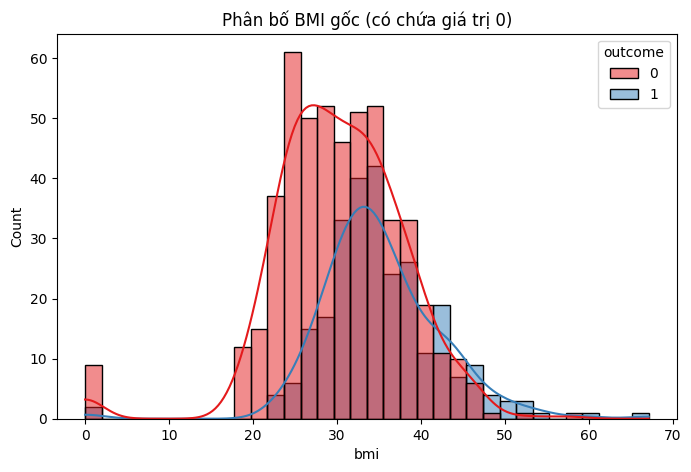

In [13]:
fig_raw, ax_raw = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df, 
    x="bmi", 
    hue="outcome", 
    kde=True, 
    ax=ax_raw,
    palette="Set1"
)
ax_raw.set_title("Phân bố BMI gốc (có chứa giá trị 0)")
plt.show()

Biểu đồ trên cho thấy có một số ít bản ghi có giá trị `bmi` bằng 0 nằm tách biệt về phía bên trái trục hoành. Chúng ta sẽ đếm chính xác số lượng và tỷ lệ phần trăm của các bản ghi bất thường này trong tập dữ liệu.

In [14]:
zero_count = (df['bmi'] == 0).sum()
zero_rate = (zero_count / len(df)) * 100

print(f"Số lượng người có mức BMI bằng 0: {zero_count} ({zero_rate:.2f}% tập dữ liệu)")

Số lượng người có mức BMI bằng 0: 11 (1.43% tập dữ liệu)


## 3. Điền khuyết bằng Trung vị (Median)
Thay vì chuyển các giá trị 0 thành `NaN` (Missing Values), trong test này chúng ta sẽ **điền khuyết** chúng bằng giá trị **trung vị** của các bản ghi có BMI hợp lệ. 
Sử dụng trung vị thay vì trung bình là một phương pháp an toàn và ít bị ảnh hưởng bởi các giá trị ngoại lai.

In [15]:
df_imputed = df.copy()

# Tính trung vị của các giá trị BMI hợp lệ (khác 0)
median_bmi = df_imputed[df_imputed['bmi'] != 0]['bmi'].median()
print(f"Giá trị trung vị của BMI (chỉ tính các ca > 0): {median_bmi}")

# Thay thế số 0 bằng giá trị trung vị vừa tìm được
df_imputed['bmi'] = df_imputed['bmi'].replace(0, median_bmi)

# Thống kê mô tả BMI sau khi điền khuyết
df_imputed[['bmi']].describe().T

Giá trị trung vị của BMI (chỉ tính các ca > 0): 32.3


,count,mean,std,min,25%,50%,75%,max
bmi,768.0,32.455208,6.875177,18.2,27.5,32.3,36.6,67.1


Bảng thống kê cho thấy giá trị nhỏ nhất (min) của BMI hiện tại đã không còn là 0. Tiếp theo, hãy xem biểu đồ phân bố của BMI sau khi được điền khuyết.

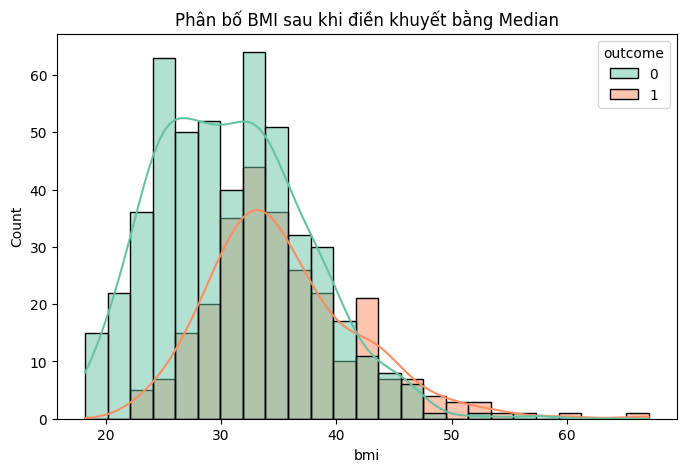

In [16]:
fig_clean, ax_clean = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df_imputed, 
    x="bmi", 
    hue="outcome", 
    kde=True, 
    ax=ax_clean,
    palette="Set2"
)
ax_clean.set_title("Phân bố BMI sau khi điền khuyết bằng Median")
plt.show()

## 4. Trực quan hóa dữ liệu sau điền khuyết
### Boxplot phân bố BMI theo kết quả chẩn đoán (Outcome)
Biểu đồ Boxplot giúp chúng ta quan sát rõ hơn sự khác biệt về trung vị và độ phân tán của chỉ số BMI giữa hai nhóm: không mắc bệnh (Outcome=0) và mắc bệnh (Outcome=1).

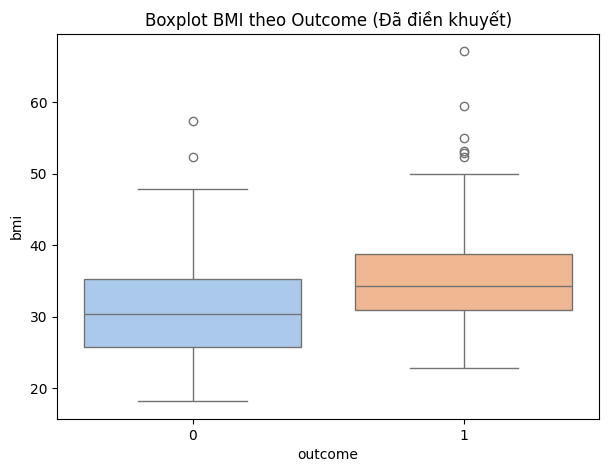

In [17]:
fig_box, ax_box = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=df_imputed,
    x="outcome",
    y="bmi",
    hue="outcome",        
    legend=False,         
    ax=ax_box,
    palette="pastel"
)
ax_box.set_title("Boxplot BMI theo Outcome (Đã điền khuyết)")
plt.show()

### Mối tương quan giữa Glucose và BMI
Cuối cùng, chúng ta xem xét sự tương quan giữa nồng độ Glucose và chỉ số BMI. Màu sắc hiển thị theo từng phân lớp `Outcome` sẽ cho thấy mức độ tập trung nguy cơ của bệnh.

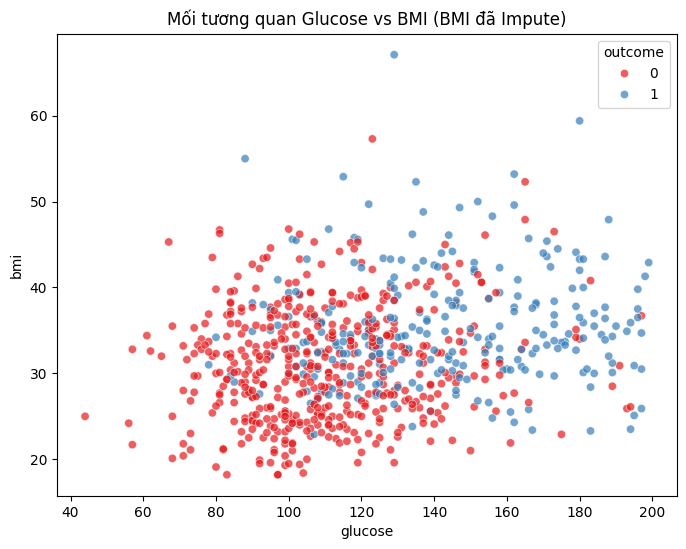

In [18]:
# Mối tương quan giữa Glucose và BMI sau khi điền khuyết
fig_scatter, ax_scatter = plt.subplots(figsize=(8, 6))

plot_df = df_imputed.copy()
plot_df['glucose'] = plot_df['glucose'].replace(0, float('nan'))

sns.scatterplot(
    data=plot_df,
    x="glucose",
    y="bmi",
    hue="outcome",
    alpha=0.7,
    ax=ax_scatter,
    palette="Set1"
)
ax_scatter.set_title("Mối tương quan Glucose vs BMI (BMI đã Impute)")
plt.show()

## 5. Kết luận
- **Xử lý giá trị lỗi:** Các giá trị BMI = 0 đã được phát hiện và thay thế bằng trung vị đảm bảo không bị mất đi dữ liệu nào.
- **Phân bố:** Việc điền khuyết giúp phân bố dữ liệu liền mạch và phản ánh một cách thực tế hơn về đối tượng bệnh nhân.
- **Mối liên hệ với Outcome:** Boxplot và Scatterplot chứng minh một cách trực quan rằng những người mắc tiểu đường (Outcome = 1) có xu hướng sở hữu chỉ số BMI và Glucose cao hơn rõ rệt so với người không mắc bệnh (Outcome = 0), cho thấy BMI là một biến rất có giá trị trong việc phân loại.